In [1]:
import sys as _sys
from pathlib import Path as _Path
try:
    _sys.path.insert(0, str(_Path(__vsc_ipynb_file__).parent.parent))
except NameError:
    pass  # Not in VS Code; rely on pip install -e .

import os
from scripts.utils import setup_notebook, OKABE_ITO_CYCLE

PROJECT_ROOT, np, pd, plt, Path = setup_notebook()

from scripts.data_loader import AHE_hysteresis
from scripts.ahe_collection import AHE_Collection

color_values = OKABE_ITO_CYCLE
Save = True

RAW_DATA_DIR = PROJECT_ROOT / "data" / "Training effect"
PLOTS_DIR    = PROJECT_ROOT / "figures"
RESULTS_DIR  = PROJECT_ROOT / "results"
PLOTS_DIR.mkdir(exist_ok=True)

folder = RAW_DATA_DIR
print(f"Raw data folder: {RAW_DATA_DIR}")
print(f"Figures folder: {PLOTS_DIR}")

[OK] Autoreload enabled
[OK] Project root: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!
Raw data folder: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr\data\Training effect
Figures folder: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr\figures


In [2]:
custom_keys = {
    "01_FC2500mT_20250319_2120__10K.h5": "Loop 1",
    "02_FC2500mT_20250319_2358__10K.h5": "Loop 2",
    "03_FC2500mT_20250320_0231__10K.h5": "Loop 3",
    "04_FC2500mT_20250320_0504__10K.h5": "Loop 4",
    "05_FC2500mT_20250320_0738__10K.h5": "Loop 5"
}
EBvT_PF_P = AHE_Collection(RAW_DATA_DIR, custom_keys)
print(EBvT_PF_P.measurements.items())

dict_items([('Loop 1', <scripts.data_loader.AHE_hysteresis object at 0x000001B722459400>), ('Loop 2', <scripts.data_loader.AHE_hysteresis object at 0x000001B72236FED0>), ('Loop 3', <scripts.data_loader.AHE_hysteresis object at 0x000001B71EBB1D10>), ('Loop 4', <scripts.data_loader.AHE_hysteresis object at 0x000001B7223CF5C0>), ('Loop 5', <scripts.data_loader.AHE_hysteresis object at 0x000001B7223CF6F0>)])


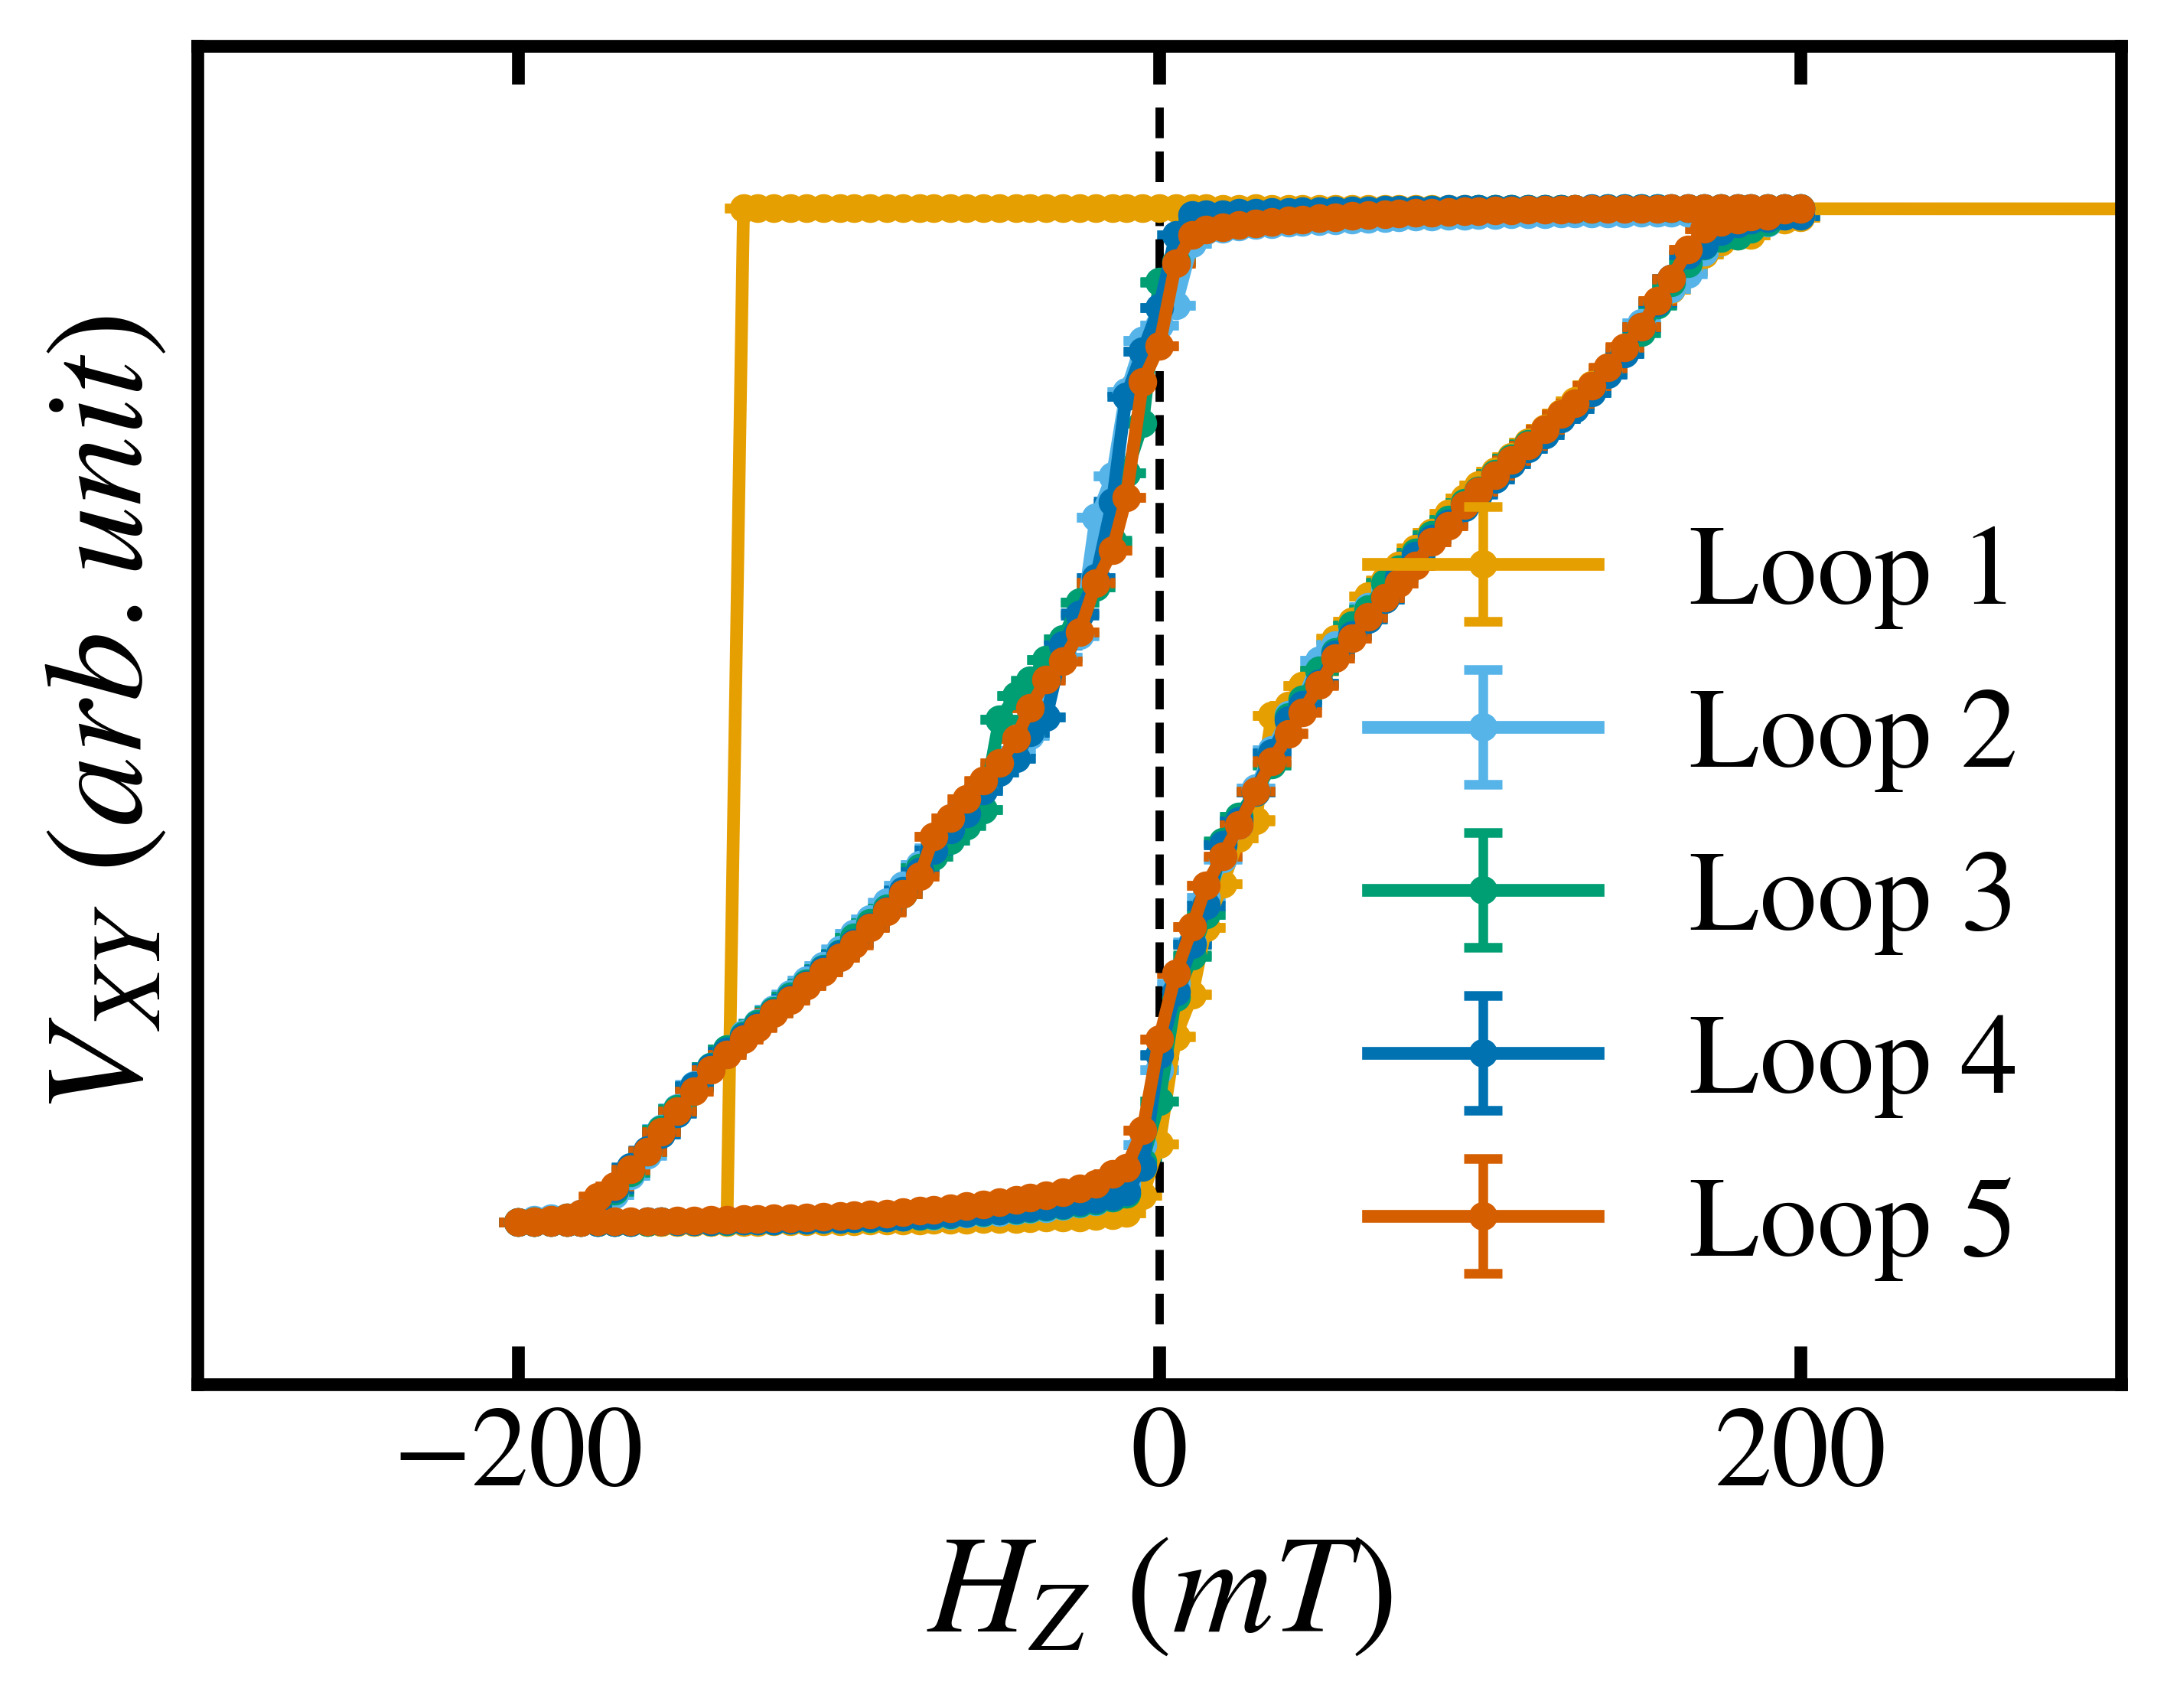

In [3]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=600)

for i, (key, obj) in enumerate(EBvT_PF_P.measurements.items()):
    vspacing = 0
    color = color_values[i % len(color_values)]
    ax.errorbar(obj.field, obj.vxy_norm - vspacing*i, obj.vxy_err/obj.vahe, fmt='-o',
    color=color,
    label=key,
    capsize=3, markersize = 3,
    elinewidth=1.5,
    markeredgewidth=1.5)



# --- Vertical zero line ---
ax.plot([0, 0], [1.2, -1.2], color='k', linestyle='--', linewidth=1.3)

ax.set_xlabel("$H_Z$ $(mT)$")
ax.set_ylabel("$V_{XY}$ $(arb. unit)$")
ax.set_yticks([])  # Remove y-axis ticks for clean stacking
ax.legend(loc='lower right',  frameon=False)
plt.tight_layout()
plt.xlim(-300,300)




plt.savefig(os.path.join(PLOTS_DIR,"Training_effect_PFP2500mT.png"))
plt.show()